In [103]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [104]:
# import layers and combine in one dataset
ds = xr.Dataset({
    "study_area": rxr.open_rasterio('output-data/study-area/study_area.tif'),
    # predictors
    "hfp": rxr.open_rasterio('output-data/predictor-layers/hfp.tif'),
    "drainage_dist": rxr.open_rasterio("output-data/predictor-layers/drainage-dist.tif"),
    "forest_dist": rxr.open_rasterio("output-data/predictor-layers/forest-dist.tif"),
    "pre_fire_evi": rxr.open_rasterio("output-data/predictor-layers/evi_pre.tif"),
    'aridity_index': rxr.open_rasterio('output-data/predictor-layers/aridity_index.tif'),
    'fire_history': rxr.open_rasterio('output-data/predictor-layers/fire_count.tif'),
    'dnbr': rxr.open_rasterio('output-data/predictor-layers/dnbr.tif'),
    'elevation': rxr.open_rasterio('output-data/predictor-layers/elevation.tif'),
    # target variables
    'recovery_2y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2017.tif"),
    'recovery_5y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2020.tif"),
    'recovery_2y_no_neg': rxr.open_rasterio("output-data/target-variables/recovery_rate_2017_no_neg.tif"),
    'recovery_5y_no_neg': rxr.open_rasterio("output-data/target-variables/recovery_rate_2020_no_neg.tif"),
    
    'aridity_index_clean': rxr.open_rasterio('output-data/predictor-layers/aridity_index_clean.tif'),
})

In [105]:
from pathlib import Path

study_mask = ds["study_area"] == 1
output_dir = Path("output-data/figures/histograms")
output_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
})

plot_labels = {
    "hfp": "Human Footprint Index",
    "drainage_dist": "Distance to Drainage (m)",
    "forest_dist": "Distance to Forest (m)",
    "pre_fire_evi": "Pre-fire EVI",
    "aridity_index": "Aridity Index",
    "fire_history": "Fire History (count)",
    "dnbr": "dNBR",
    "elevation": "Elevation (m)",
    "recovery_2y": "Vegetation Recovery Rate (%)",
    "recovery_5y": "Vegetation Recovery Rate (%)",
    "recovery_2y_no_neg": "Vegetation Recovery Rate (%)",
    "recovery_5y_no_neg": "Vegetation Recovery Rate (%)",
    "aridity_index_clean": "Aridity Index",
}

plot_colors = {
    "hfp": "#5ab4ac",
    "drainage_dist": "#5ab4ac",
    "forest_dist": "#5ab4ac",
    "pre_fire_evi": "#5ab4ac",
    "aridity_index":"#5ab4ac",
    "fire_history": "#5ab4ac",
    "dnbr": "#5ab4ac",
    "elevation": "#5ab4ac",
    "recovery_2y": "#8fb6d8",
    "recovery_5y": "#f3b37a",
    "recovery_2y_no_neg": "#8fb6d8",
    "recovery_5y_no_neg": "#f3b37a",
}

def extract_clean_values(da, exclude_values=None):
    vals = da.where(study_mask).values.flatten().astype(float)
    nodata = da.rio.nodata
    if nodata is not None:
        vals = vals[vals != nodata]
    vals = vals[np.isfinite(vals)]
    if exclude_values is not None:
        exclude_values = np.atleast_1d(exclude_values)
        vals = vals[~np.isin(vals, exclude_values)]
    return vals

def format_hist_axes(ax):
    ax.set_axisbelow(True)
    ax.grid(True, color="#9a9a9a", alpha=0.55, linewidth=1)

    x_max = max(abs(v) for v in ax.get_xlim())
    y_max = max(abs(v) for v in ax.get_ylim())

    if y_max >= 10000:
        ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

def plot_variable_histogram(var_name, title=None, color=None, bins=60, exclude_values=None, filename=None):
    vals = extract_clean_values(ds[var_name], exclude_values=exclude_values)
    label = f"mean: {np.mean(vals):.2f} ± {np.std(vals):.2f}"

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(
        vals,
        bins=bins,
        ax=ax,
        kde=False,
        color=color or plot_colors.get(var_name, "#8fb6d8"),
        alpha=0.75,
        edgecolor=None,
        label=label,
    )
    ax.set_xlabel(plot_labels.get(var_name, var_name))
    ax.set_ylabel("n")
    format_hist_axes(ax)
    ax.legend(loc="upper right", frameon=True)

    fig.tight_layout()
    output_path = output_dir / (filename or f"hist_{var_name}.png")
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()

Saved: output-data/figures/histograms/hist_hfp.png


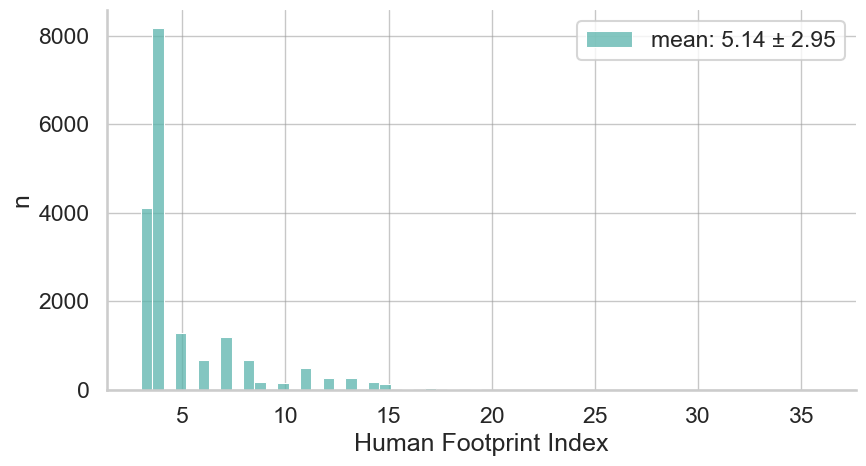

In [106]:
plot_variable_histogram(
    "hfp",
)

Saved: output-data/figures/histograms/hist_drainage_dist.png


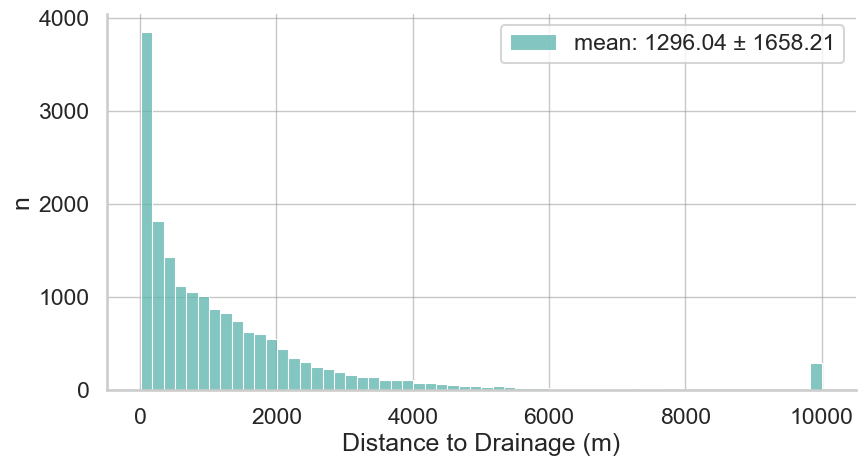

In [107]:
plot_variable_histogram(
    "drainage_dist",
)

Study-area pixels with value 10000: 290 of 17,989 (1.61%)
Saved: output-data/figures/histograms/hist_drainage_dist.png


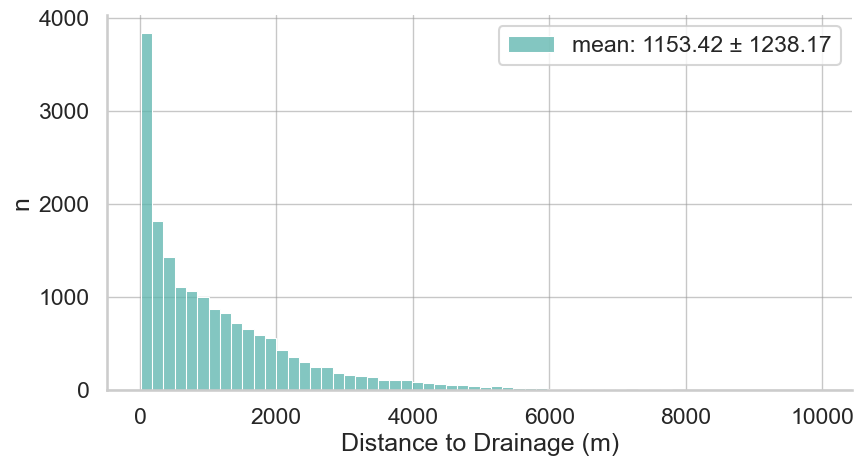

In [108]:
drain_vals = extract_clean_values(ds["drainage_dist"])
n_total = len(drain_vals)
n_10000 = int(np.sum(drain_vals == 10000))
pct_10000 = (n_10000 / n_total) * 100 if n_total else 0

print(f"Study-area pixels with value 10000: {n_10000:,} of {n_total:,} ({pct_10000:.2f}%)")

plot_variable_histogram(
    "drainage_dist",
    color="#5ab4ac",
    exclude_values=10000,
)

Saved: output-data/figures/histograms/hist_forest_dist.png


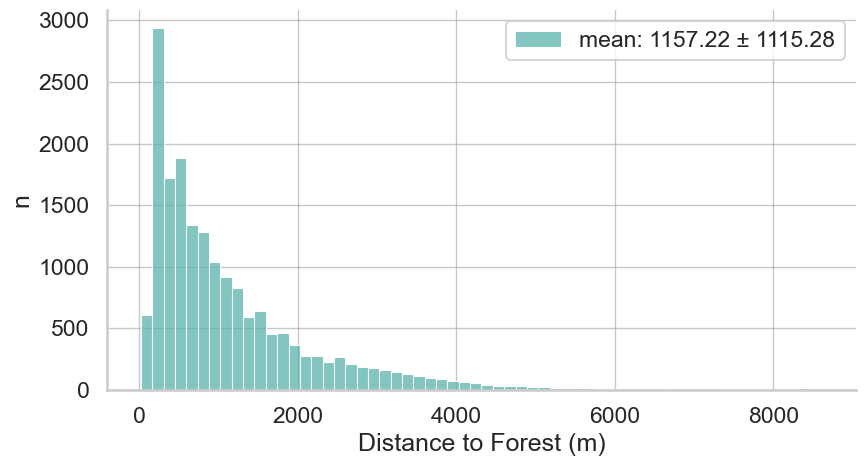

In [109]:
plot_variable_histogram(
    "forest_dist",
)

Saved: output-data/figures/histograms/hist_pre_fire_evi.png


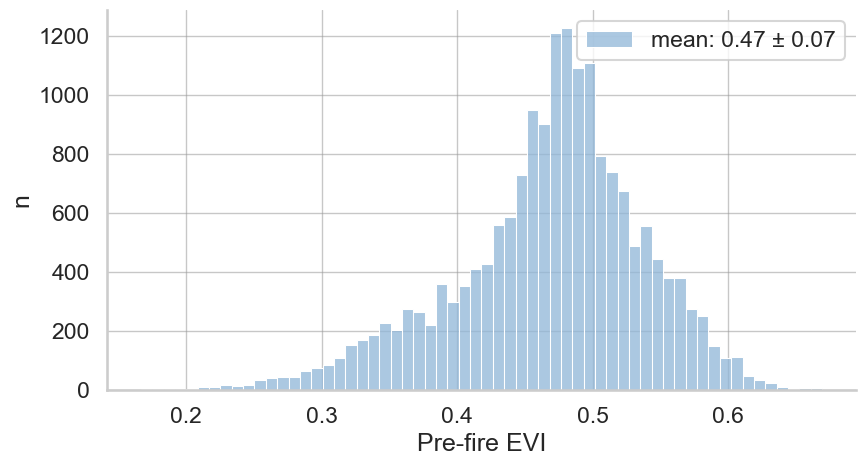

In [110]:
plot_variable_histogram(
    "pre_fire_evi",
    color="#8fb6d8",
)

Saved: output-data/figures/histograms/hist_aridity_index.png


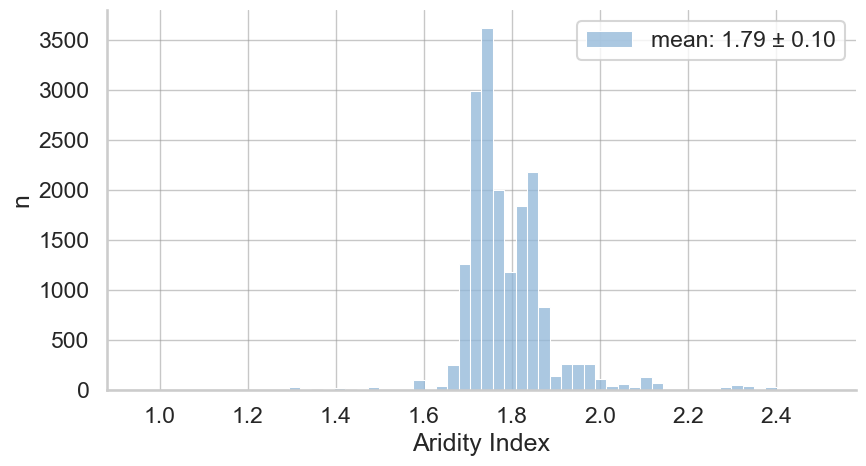

In [111]:
plot_variable_histogram(
    "aridity_index",
    color="#8fb6d8",
)

Saved: output-data/figures/histograms/hist_fire_history.png


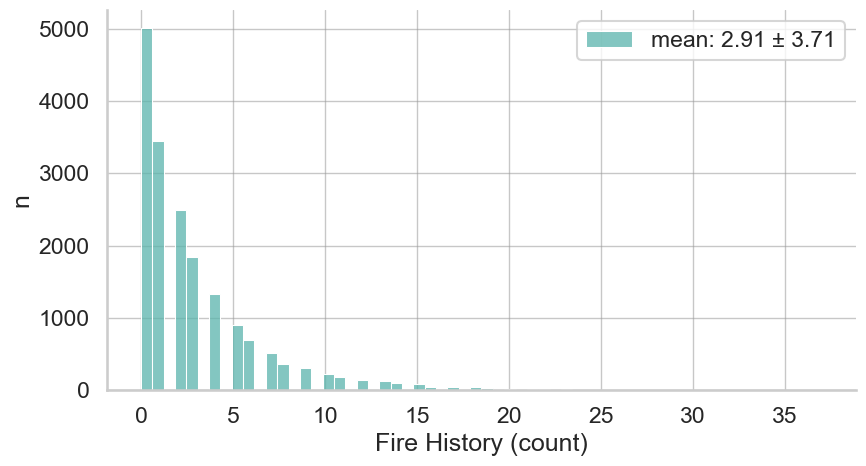

In [120]:
plot_variable_histogram(
    "fire_history"
)

Saved: output-data/figures/histograms/hist_dnbr.png


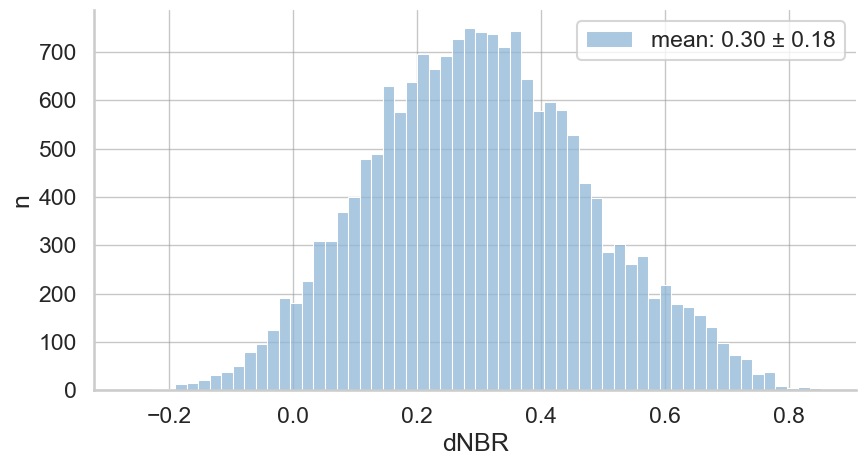

In [113]:
plot_variable_histogram(
    "dnbr",
    title="dNBR",
    color="#8fb6d8",
)

Saved: output-data/figures/histograms/hist_elevation.png


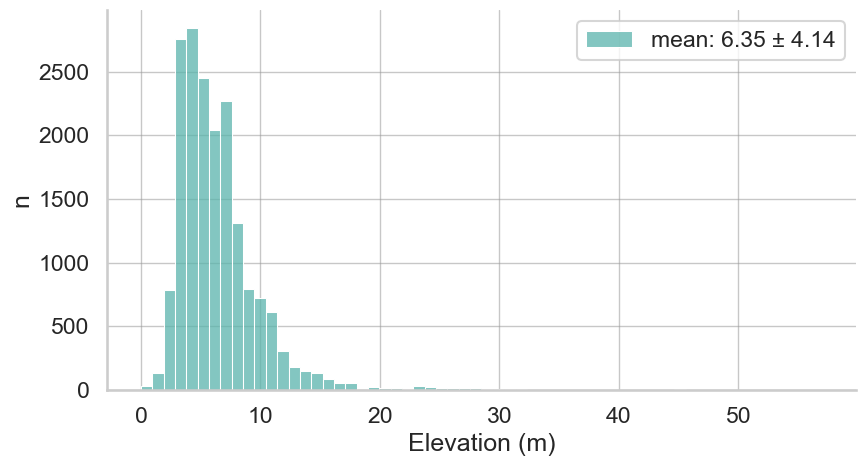

In [119]:
plot_variable_histogram(
    "elevation",
    title="Elevation",
)

Saved: output-data/figures/histograms/hist_recovery_2y.png


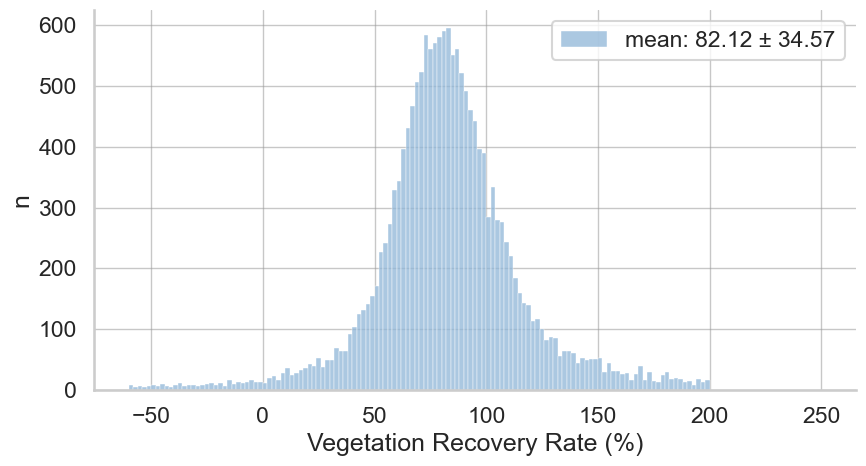

In [115]:
plot_variable_histogram(
    "recovery_2y",
    title="Vegetation Recovery Rate 2017",
    color="#8fb6d8",
    bins=np.arange(-60, 251, 2),
)

Saved: output-data/figures/histograms/hist_recovery_5y.png


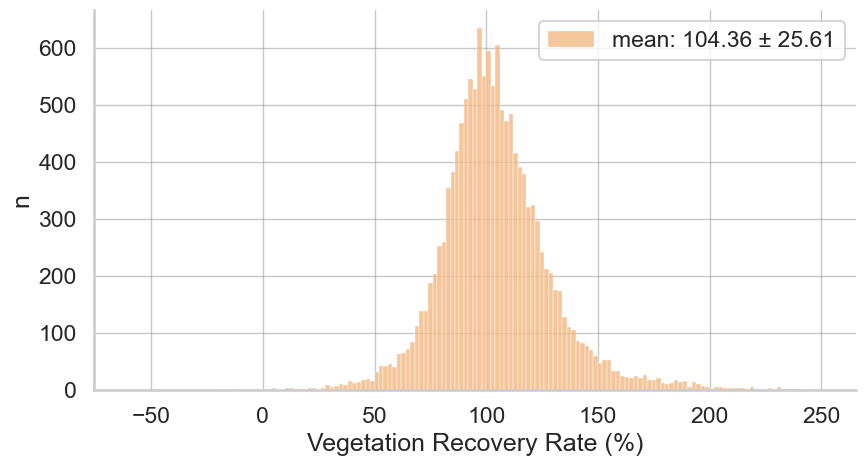

In [116]:
plot_variable_histogram(
    "recovery_5y",
    title="Vegetation Recovery Rate 2020",
    color="#f3b37a",
    bins=np.arange(-60, 251, 2),
)

Saved: output-data/figures/histograms/hist_recovery_2y_no_neg.png


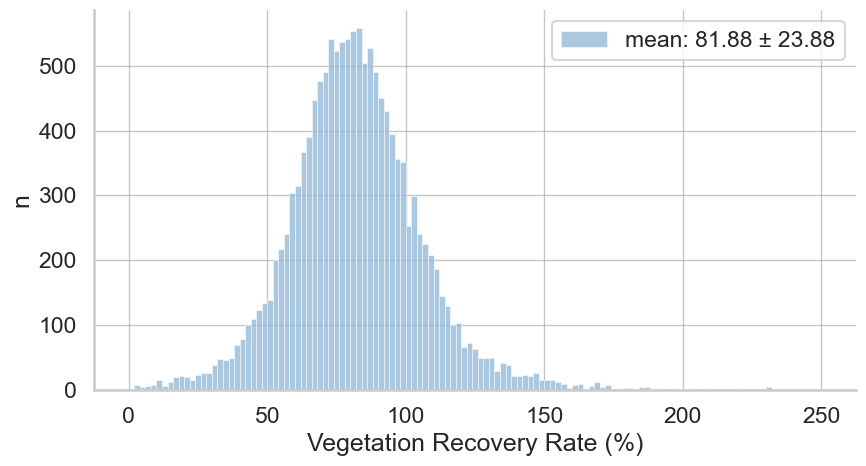

In [117]:
plot_variable_histogram(
    "recovery_2y_no_neg",
    title="Vegetation Recovery Rate 2017 (no negatives)",
    color="#8fb6d8",
    bins=np.arange(0, 251, 2),
)

Saved: output-data/figures/histograms/hist_recovery_5y_no_neg.png


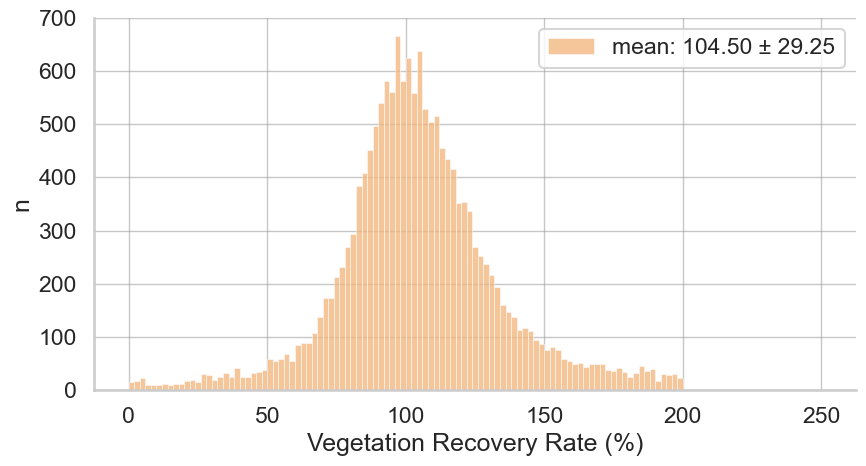

In [118]:
plot_variable_histogram(
    "recovery_5y_no_neg",
    title="Vegetation Recovery Rate 2020 (no negatives)",
    color="#f3b37a",
    bins=np.arange(0, 251, 2),
)